In [ ]:
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [303]:
class DataLoader:
    def __init__(self, path):
        self.path = path

    
    def wrangle_data(self):
        df = pd.read_csv(self.path)

        # Drop some columns
        df_clean = df.drop(columns=["name", "CID", "CAS", "year", "ppdb_level"])

        df_clean = pd.get_dummies(df_clean, columns=["source", "toxicity_type"], dtype=int)

        return df_clean


In [304]:
# Convert SMILES feature into fingerprints

class Encoder:
    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

    def smiles_to_morgan(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
    
        if mol is None:
            return None
    
        fp = self.morgan_gen.GetFingerprint(mol)
    
        return list(fp)
    
    def transform(self, df):

        fingerprints = df["SMILES"].apply(self.smiles_to_morgan)

        valid_rows = fingerprints.notnull()

        df = df[valid_rows].reset_index(drop=True)
        fingerprints = fingerprints[valid_rows]

        fp_df = pd.DataFrame(fingerprints.tolist(), columns=[f"SMILES_fp_{i}" for i in range(2048)])

        df = df.drop(columns=["SMILES"])

        df_final = pd.concat(
            [df.reset_index(drop=True),
             fp_df.reset_index(drop=True)],
            axis=1
        )

        return df_final


In [305]:
class ModelTrainer:
    def __init__(self, X, y):
        self.X = X
        self.y = y

        self.X_train= None
        self.X_test= None
        self.y_train= None
        self.y_test= None

        self.model = None

    def split_data(self):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            train_size=0.8,
            random_state=42,
            stratify=self.y
        )

    
    def build_pipeline(self):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000))
        ])
        
        return pipe


    def train_model(self):
        pipe = self.build_pipeline()

        param_grid = [
            {
                "model": [RandomForestClassifier(class_weight="balanced")],
                "model__n_estimators": [100, 200, 500],
                "model__max_depth": [None, 10, 20],
                "model__min_samples_split": [2, 5, 10] 
            },

            {
               "model": [LogisticRegression(class_weight="balanced")],
                "model__C": [0.01, 0.1, 1, 10]
            }
        ]

        grid = GridSearchCV(
            pipe,
            param_grid=param_grid,
            cv=5,
            scoring="f1_weighted",
            n_jobs=-1,
            verbose=2
        )
        
        
        grid.fit(self.X_train, self.y_train)

        self.best_model = grid.best_estimator_

        print(f"Best Model: {self.best_model}")
        print(f"Best Parameters: {grid.best_params_}")

    # Evaluate the model
    def evaluate(self):
        y_pred = self.best_model.predict(self.X_test)
        
        acc = accuracy_score(self.y_test, y_pred)
        report = classification_report(self.y_test, y_pred)
        cm = confusion_matrix(self.y_test, y_pred)

        print(f"Accuracy: {acc:.4f}\n")
        print(f"Classification Report: {report}\n")
        print(f"Confusion Matrix: {cm}")


        # Plot Confusion Matrix Heatmap
        plt.figure(figsize=(6, 5))

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues"
        )
    
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
    
        plt.show();
        

    def save_model(self, filename):
        joblib.dump(self.best_model, filename)

In [306]:
def run():
    loader = DataLoader("data/dataset_final.csv")

    encoder = Encoder()

    df = loader.wrangle_data()
    df = encoder.transform(df)

    # print(df.info(max_cols=3000))

    X = df.drop(["label"], axis=1)
    y = df["label"]

    print(X.shape)
    print(y.shape)

    # print(y.value_counts())
    # print(y.value_counts(normalize=True))

    trainer = ModelTrainer(X, y)

    trainer.split_data()
    trainer.train_model()
    trainer.evaluate()

    trainer.save_model("apistox_model.pkl")
    
    return df.head()

(1035, 2058)
(1035,)
Fitting 5 folds for each of 31 candidates, totalling 155 fits
Best Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(class_weight='balanced'))])
Best Parameters: {'model': RandomForestClassifier(class_weight='balanced'), 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Accuracy: 0.8792

Classification Report:               precision    recall  f1-score   support

           0       0.87      0.97      0.92       148
           1       0.90      0.64      0.75        59

    accuracy                           0.88       207
   macro avg       0.89      0.81      0.84       207
weighted avg       0.88      0.88      0.87       207


Confusion Matrix: [[144   4]
 [ 21  38]]


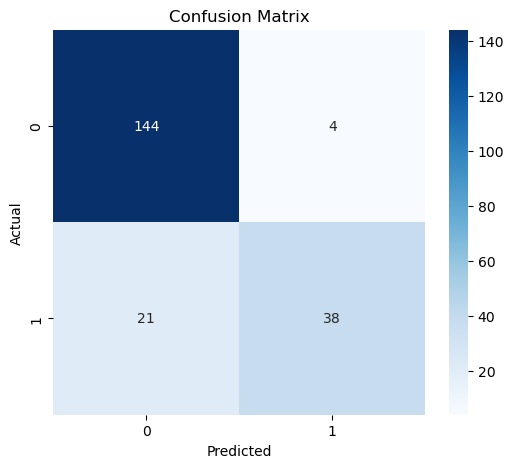

,herbicide,fungicide,insecticide,other_agrochemical,label,source_BPDB,source_ECOTOX,source_PPDB,toxicity_type_Contact,toxicity_type_Oral,...,SMILES_fp_2038,SMILES_fp_2039,SMILES_fp_2040,SMILES_fp_2041,SMILES_fp_2042,SMILES_fp_2043,SMILES_fp_2044,SMILES_fp_2045,SMILES_fp_2046,SMILES_fp_2047
0,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [307]:
run()

In [308]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                1035 non-null   object
 1   CID                 1035 non-null   int64 
 2   CAS                 1035 non-null   object
 3   SMILES              1035 non-null   object
 4   source              1035 non-null   object
 5   year                1035 non-null   int64 
 6   toxicity_type       1035 non-null   object
 7   herbicide           1035 non-null   int64 
 8   fungicide           1035 non-null   int64 
 9   insecticide         1035 non-null   int64 
 10  other_agrochemical  1035 non-null   int64 
 11  label               1035 non-null   int64 
 12  ppdb_level          1035 non-null   int64 
dtypes: int64(8), object(5)
memory usage: 105.2+ KB


In [309]:
df.columns

Index(['name', 'CID', 'CAS', 'SMILES', 'source', 'year', 'toxicity_type',
       'herbicide', 'fungicide', 'insecticide', 'other_agrochemical', 'label',
       'ppdb_level'],
      dtype='object')

In [310]:
corr_matrix = df.select_dtypes("number").corr()

print(corr_matrix["label"].sort_values(ascending=False))

label                 1.000000
ppdb_level            0.636893
insecticide           0.517132
CID                  -0.029227
other_agrochemical   -0.051425
year                 -0.086647
fungicide            -0.170694
herbicide            -0.330103
Name: label, dtype: float64


## Correlation Heatmap

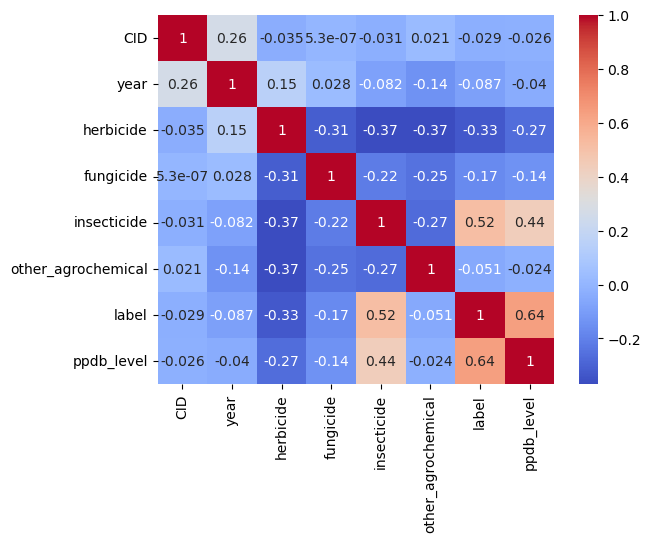

In [311]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show();

In [312]:
df.head()

,name,CID,CAS,SMILES,source,year,toxicity_type,herbicide,fungicide,insecticide,other_agrochemical,label,ppdb_level
0,Ethanedioic acid,971,144-62-7,O=C(O)C(=O)O,ECOTOX,1832,Contact,0,0,0,0,0,0
1,Para-cymene,7463,99-87-6,Cc1ccc(C(C)C)cc1,BPDB,1833,Other,0,0,0,1,0,1
2,Kieselguhr,24261,61790-53-2,O=[Si]=O,ECOTOX,1833,Contact,0,0,0,0,0,0
3,Benzoic acid,243,65-85-0,O=C(O)c1ccccc1,ECOTOX,1833,Contact,1,1,1,0,0,1
4,Tetradifon (Ref: ENT 23737),8305,116-29-0,O=S(=O)(c1ccc(Cl)cc1)c1cc(Cl)c(Cl)cc1Cl,PPDB,1836,Oral,0,0,0,1,1,1
